# Deep Learning: LSTMs

In Lesson 13, we forced Machine Learning models (like XGBoost) to understand time by manually engineering Lag features. We took a 1D timeline and chopped it into a 2D matrix.

But what if you didn't have to manually engineer the memory? What if the algorithm *natively* understood the flow of time, read the data chronologically, and mathematically decided for itself which historical events were worth remembering and which should be forgotten?

Welcome to Deep Learning for Time Series. In this lesson, we will explore the architecture that revolutionized speech recognition, translation, and forecasting: the **Long Short-Term Memory (LSTM)** network.

LSTMs are a specialized variant of Recurrent Neural Networks (RNNs). While standard Feedforward Neural Networks pass data strictly forward, RNNs contain "loops" that allow information to persist. They pass a "Hidden State" ($h_t$) from one time step to the next.

Let's set up our Python environment using TensorFlow/Keras to build a deep sequence model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

import os

os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Deep Learning Sequence Environment Ready.")

2026-05-19 14:24:44.735913: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Deep Learning Sequence Environment Ready.


# 1. The Fatal Flaw of Vanilla RNNs (Vanishing Gradients)

Standard RNNs have a massive mathematical vulnerability.

When an RNN tries to connect a piece of information from Day 1 to a prediction it needs to make on Day 100, it must multiply the data by a weight matrix 100 times in a row.
If those weights are slightly less than $1.0$, multiplying a fraction by itself 100 times causes the value to exponentially decay to exactly zero ($0.9^{100} \approx 0.00002$).

This is the **Vanishing Gradient Problem**. The RNN literally suffers from amnesia. It can remember what happened yesterday, but it completely loses the signal of what happened a month ago.


# 2. The Anatomy of an LSTM

In 1997, Hochreiter and Schmidhuber solved this by inventing the LSTM. Instead of a single, simple hidden state, an LSTM cell contains a complex internal architecture consisting of a **Cell State** and three **Gates**.

### The Cell State ($C_t$)

Think of this as a conveyor belt running straight down the entire timeline of the network. Information can flow down this belt unchanged, completely bypassing the vanishing gradient problem. The LSTM uses gates to carefully add or remove information from this conveyor belt.

### 1. The Forget Gate ($f_t$)

The network looks at the data from today ($x_t$) and the hidden state from yesterday ($h_{t-1}$), and passes it through a Sigmoid ($\sigma$) function, outputting a number strictly between $0$ and $1$.

* $0$ means "Completely delete this memory from the conveyor belt."
* $1$ means "Keep this memory perfectly intact."

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$



### 2. The Input Gate ($i_t$)

This decides what *new* information is worth adding to the cell state. A Sigmoid decides *which* values to update, and a Tanh creates a vector of *new* candidate values ($\tilde{C}_t$).


$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

### 3. The Output Gate ($o_t$)

Finally, the cell decides what it wants to output to the next time step. It filters the updated Cell State through one last Sigmoid gate.


$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

$$h_t = o_t * \tanh(C_t)$$

# 3. The 3D Tensor Transformation

The absolute hardest part of transitioning to Deep Learning is not the math—it is the Data Engineering.

Classical ML models (like XGBoost) expect a 2D matrix: `(Samples, Features)`.
LSTMs natively understand sequence, so they demand a **3D Tensor**: `(Samples, Time_Steps, Features)`.

1. **Samples (Batch Size)**: The total number of sequences you are feeding the network.
2. **Time_Steps (Lookback Window)**: How many days of history are inside a single sequence (e.g., 30 days).
3. **Features**: How many variables you are tracking per day (e.g., 1 feature for Univariate sales; 5 features if you include temperature, marketing, etc.).

# 4. Implementing an LSTM in Code

Let's simulate a complex, noisy sine wave (representing a seasonal business metric). We will architect the 3D tensor transformation, build the LSTM network, and forecast the future.

🚨 Training Tensor Shape: (384, 20, 1)
(Samples: 384, Time Steps: 20, Features: 1)


I0000 00:00:1779189903.192879   27449 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2240 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5
/root/micromamba/envs/ds/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM Model...


2026-05-19 14:25:11.345026: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92200


✅ Training Complete.


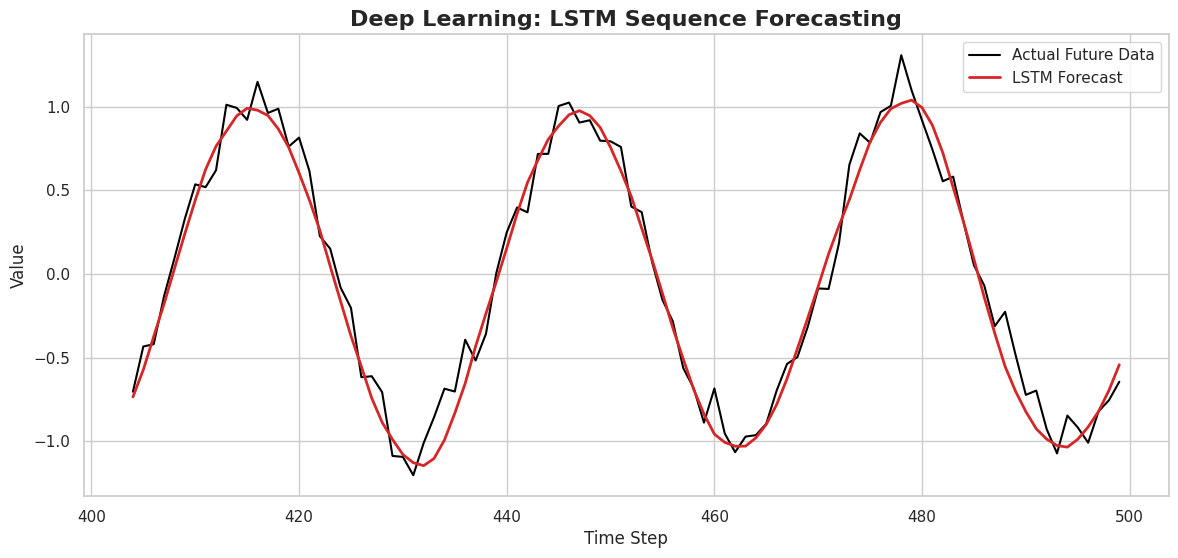

In [2]:
# 1. Simulate a Noisy Sine Wave
np.random.seed(42)
time = np.linspace(0, 100, 500)
data = np.sin(time) + np.random.normal(0, 0.1, 500)

# Neural Networks require data to be strictly scaled between 0 and 1 or -1 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1)).astype(np.float32)

# 2. Architect the 3D Tensor Transformation
def create_3d_dataset(dataset, look_back=10):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        # The sequence of historical days
        X.append(dataset[i : (i + look_back), 0])
        # The actual target day
        y.append(dataset[i + look_back, 0])
    
    # Convert to NumPy arrays
    X_array, y_array = np.array(X), np.array(y)
    
    # CRITICAL: Reshape to 3D Tensor -> (Samples, Time_Steps, Features)
    # Features = 1 because this is a univariate series
    X_3d = np.reshape(X_array, (X_array.shape[0], X_array.shape[1], 1))
    return X_3d, y_array

look_back = 20
X, y = create_3d_dataset(data_scaled, look_back)

# Split into Train and Test (Chronologically)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"🚨 Training Tensor Shape: {X_train.shape}")
print(f"(Samples: {X_train.shape[0]}, Time Steps: {X_train.shape[1]}, Features: {X_train.shape[2]})")

# 3. Build the Deep Learning Architecture
model = Sequential()

# Add the LSTM layer
# input_shape strictly expects (Time_Steps, Features)
model.add(LSTM(units=50, return_sequences=False, input_shape=(look_back, 1)))

# Add a dense output layer (Predicting 1 step ahead)
model.add(Dense(units=1))

# Compile the graph using the Adam optimizer and Mean Squared Error loss
model.compile(optimizer='adam', loss='mean_squared_error' , jit_compile=False)

# 4. Train the Network
print("\nTraining LSTM Model...")
# epochs = how many times to pass the entire dataset through the network
# batch_size = how many sequences to process simultaneously before updating weights
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test), verbose=0)
print("✅ Training Complete.")

# 5. Generate Forecasts and Inverse Scale
train_predict = model.predict(X_train, verbose=0)
test_predict = model.predict(X_test, verbose=0)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# 6. Matplotlib Visualization
plt.figure(figsize=(14, 6))

# Plot the Actual Data
actual_test_time = np.arange(split + look_back, len(data))
plt.plot(actual_test_time, y_test_unscaled, color='black', label='Actual Future Data')

# Plot the LSTM Prediction
plt.plot(actual_test_time, test_predict, color='#d62728', linewidth=2, label='LSTM Forecast')

plt.title("Deep Learning: LSTM Sequence Forecasting", fontsize=16, fontweight='bold')
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend(loc='upper right')
plt.show()

## Real-World Use Case or Analogy:

Think of an LSTM like **Reading a Mystery Novel**:

* **Standard RNN (Short-Term Memory)**: As you read a sentence on page 300, you only remember the sentence you just read on page 299. When the killer is revealed on page 300, you have completely forgotten the subtle clue the author dropped on page 2 (The Vanishing Gradient).
* **The LSTM Cell State**: This is your notebook. It sits next to the book, preserving information independently of the page you are currently reading.
* **The Input Gate**: You read a new clue on page 150. You decide it is important, so you write it down in your notebook.
* **The Forget Gate**: You reach page 200, and a character is proven innocent. You take an eraser, open your notebook, and physically delete their name (dropping information from the Cell State) so it doesn't clutter your memory.
* **The Output Gate**: The detective asks, "Who is the killer?" You combine the current paragraph you are reading with the highly-curated long-term clues in your notebook to generate your final answer.